# Face Recognition: A Comparative Analysis of SVM and MLP on the ORL Database

Axel Omar Sanchez Peralta (UCID: 30145429) · Mariia Podgaietska

## 1. Introduction & Motivation

Face recognition is a fundamental problem in computer vision with applications ranging from biometric authentication to human–computer interaction. Given a probe image of an unknown individual, a recognition system must reliably match it against a gallery of known subjects — a task that is complicated by intra-class variability in illumination, pose, and expression.

This notebook presents a systematic comparison of two classical supervised learning paradigms on the **ORL (AT&T) face database**: the **Support Vector Machine (SVM)** and the **Multi-Layer Perceptron (MLP)**. Both models are evaluated under three feature representations:

| Feature | Description |
|---------|-------------|
| **Raw pixels** | Flattened, normalised grayscale intensity vector |
| **LBP histogram** | Local Binary Pattern texture descriptor (P=12, R=3) |
| **PCA projection** | Principal-component subspace of dimension 100 |

**Project objectives:**
1. Implement a reproducible, stratified train/test split to prevent subject leakage.
2. Tune both models with `HalvingRandomSearchCV` for efficient hyperparameter search.
3. Compare performance quantitatively via accuracy, ROC AUC, and DET curves.
4. Provide interpretable guidance on when to prefer SVM over MLP and vice versa.

## 2. Setup

In [37]:
import os, zipfile, time
from pathlib import Path

import requests
import cv2
import numpy as np
from glob import glob

from skimage.feature import local_binary_pattern

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_halving_search_cv  # must precede next import
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, det_curve

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

## 3. Dataset Description

The **ORL (Olivetti Research Laboratory) database**, now maintained by AT&T Laboratories Cambridge, contains **400 grayscale images** of 40 distinct subjects, with 10 images per subject. Each image has a resolution of 92 × 112 pixels (8-bit depth). The collection exhibits controlled but realistic variability:

- **Lighting:** slight changes in illumination across sessions.
- **Expression:** open/closed eyes, smiling/non-smiling faces.
- **Facial details:** presence or absence of glasses.
- **Pose:** small rotations and tilts (up to 20°).

**Stratified split strategy.** We use `train_test_split` with `stratify=y` and `test_size=0.2`, ensuring that each of the 40 subjects contributes exactly 8 images to the training set and 2 images to the test set (320 train / 80 test). Stratification prevents the class-imbalance artefacts that arise from a naïve random split and guarantees that every subject appears in both partitions.

### 3.1 Download Dataset Function

To ensure reproducibility we implement a function that downloads the zipped dataset from our repository and extracts it to a specified directory. This function checks if the dataset already exists locally to avoid redundant downloads.

In [38]:
def download_data(source: str, destination: str, remove_source: bool = True) -> Path:
    """Downloads a zipped dataset from source and unzips to destination.

    Args:
        source: URL of the zip file.
        destination: Target sub-directory inside data/.
        remove_source: Remove the zip after extraction.

    Returns:
        pathlib.Path to the extracted directory.
    """
    data_path = Path("data/")
    image_path = data_path / destination

    if image_path.is_dir():
        print(f"[INFO] {image_path} directory exists, skipping download.")
    else:
        print(f"[INFO] Creating {image_path}...")
        image_path.mkdir(parents=True, exist_ok=True)
        target_file = Path(source).name
        print(f"[INFO] Downloading {target_file}...")
        with requests.get(source, stream=True, timeout=30) as r:
            r.raise_for_status()
            with open(data_path / target_file, 'wb') as f:
                for chunk in r.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)
        with zipfile.ZipFile(data_path / target_file, 'r') as zf:
            print(f"[INFO] Unzipping {target_file}...")
            zf.extractall(image_path)
        if remove_source:
            os.remove(data_path / target_file)
    return image_path

### 3.2 Resolve Dataset

The dataset is organized into a directory structure where each subject's images are stored in a separate folder named `sX` (where `X` is the subject ID from 1 to 40). Each folder contains 10 images named `Y.pgm` (where `Y` is the image number from 1 to 10).

In [39]:
dataset_dir = Path("data/dataset")
zip_path    = Path("data/dataset.zip")

if dataset_dir.exists():
    print("[INFO] Dataset already available.")
elif zip_path.exists():
    print("[INFO] Unzipping local dataset.zip...")
    dataset_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(dataset_dir)
else:
    print("[INFO] Downloading dataset from GitHub...")
    download_data(
        source="https://github.com/Axeloooo/Face-Recognition/raw/devel/data/dataset.zip",
        destination="dataset"
    )

[INFO] Dataset already available.


## 4. Feature Extraction

Raw pixel intensities are a natural baseline but are high-dimensional (92 × 112 = 10 304 features) and sensitive to illumination shifts. We therefore compare three representations that trade dimensionality for increasing degrees of invariance:

| Representation | Dimension | Invariance |
|----------------|-----------|------------|
| Raw pixels | 10 304 | None |
| LBP histogram | 64 | Monotone illumination |
| PCA projection | 100 | None (but low-rank) |

All three are computed by the unified `get_data()` function defined in [Section 4.3](#43-get-data-function), which accepts an optional `preprocessing` argument (`None`, `'lbp'`, or `'pca'`).

### 4.1 Local Binary Patterns (LBP)

![](https://github.com/Axeloooo/Face-Recognition/raw/devel/images/local-binary-pattern.png)

Local Binary Pattern (LBP) is a non-parametric texture operator that encodes the local neighbourhood of each pixel as a binary string. For a centre pixel $g_c$ with $P$ equally-spaced neighbours at radius $R$, the LBP code is:

$$\text{LBP}_{P,R}(g_c) = \sum_{p=0}^{P-1} s(g_p - g_c)\,2^p, \quad s(x) = \begin{cases}1 & x \ge 0 \\ 0 & x < 0\end{cases}$$

**Configuration used:** $P = 12$, $R = 3$, `method='default'` (full LBP, values in $[0, 2^{12}-1]$). The per-pixel LBP map is summarised as a **normalised histogram with 64 bins**, yielding a 64-dimensional descriptor per image. This compact representation is **invariant to monotone illumination changes** — a critical property for face images captured under varying lighting conditions.

### 4.2 Principal Component Analysis (PCA) — Eigenfaces

PCA finds the orthonormal basis that captures maximum variance in the training set. Applied to face images, the top eigenvectors are commonly called **eigenfaces** (Turk & Pentland, 1991). Each image $\mathbf{x} \in \mathbb{R}^{10304}$ is projected onto the $k$ leading principal components:

$$\mathbf{z} = W^\top (\mathbf{x} - \boldsymbol{\mu})$$

where $W \in \mathbb{R}^{10304 \times k}$ is the matrix of eigenvectors and $\boldsymbol{\mu}$ is the mean face.

**Configuration used:** $k = 100$ components, fitted on the training split only (to prevent data leakage). 100 components typically retain > 95 % of the total variance for ORL, compressing the input 103× while preserving the geometric structure relevant for identity discrimination.

### 4.3 Get Data Function

The `get_data()` function is a unified interface for loading the ORL dataset and applying the specified preprocessing. It accepts a `preprocessing` argument that can be set to `None`, `'lbp'`, or `'pca'` to compute the corresponding feature representation. The function handles the entire pipeline from raw image loading to feature extraction, ensuring consistency across all experiments.

In [40]:
DATA_PATH = 'data/dataset/ATT dataset/s*/**/*.pgm'


def get_data(path, preprocessing=None, **kwargs):
    """Loads images and labels from the specified path, applying optional preprocessing.

    Args:
        path (str): Glob pattern to load images (e.g., 'data/dataset/ATT dataset/s*/**/*.pgm').
        preprocessing (str, optional): Type of preprocessing to apply. Defaults to None.

    Raises:
        ValueError: If an unknown preprocessing method is specified.

    Returns:
        Tuple[np.ndarray, np.ndarray]: Tuple of (X, y) where X is the feature matrix and y is the label vector.
    """
    paths = glob(path, recursive=True)
    images, labels = [], []

    for p in paths:
        img = cv2.imread(p, 0)
        if img is None:
            continue
        parts = Path(p).parts
        subj = [x for x in parts if x.startswith('s') and x[1:].isdigit()]
        if not subj:
            continue
        images.append(img)
        labels.append(int(subj[0][1:]) - 1)

    y = np.array(labels)

    if preprocessing is None:
        print("[INFO] Using raw pixel values as features...")
        X = np.array([img.reshape(-1).astype(np.float32) / 255.0 for img in images])

    elif preprocessing == 'lbp':
        print("[INFO] Computing LBP histograms...")
        n_bins = kwargs.get('n_bins', 64)
        lbp_max = 2 ** 12
        hists = []
        for img in images:
            lbp = local_binary_pattern(img.astype(np.uint8), P=12, R=3, method='default')
            hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, lbp_max), density=True)
            hists.append(hist)
        X = np.array(hists, dtype=np.float32)

    elif preprocessing == 'pca':
        print("[INFO] Computing PCA projections...")
        n_components = kwargs.get('n_components', 100)
        X_flat = np.array([img.reshape(-1).astype(np.float32) / 255.0 for img in images])
        pca = PCA(n_components=n_components, random_state=42)
        X = pca.fit_transform(X_flat)

    else:
        raise ValueError(f"Unknown preprocessing: '{preprocessing}'")

    return X, y

### 4.4 Get All Three Preprocessing Methods

To facilitate comparison, we call `get_data()` three times with different `preprocessing` settings to obtain the raw pixel, LBP histogram, and PCA projection datasets. Each call returns the training and test splits for the respective feature representation, which are then used for model training and evaluation in subsequent sections.

In [41]:
X_raw, y = get_data(DATA_PATH)
X_lbp, _ = get_data(DATA_PATH, preprocessing='lbp', n_bins=64)
X_pca, _ = get_data(DATA_PATH, preprocessing='pca', n_components=100)

print(f'Raw  : {X_raw.shape},  LBP : {X_lbp.shape},  PCA : {X_pca.shape}')

[INFO] Using raw pixel values as features...
[INFO] Computing LBP histograms...
[INFO] Computing PCA projections...
Raw  : (400, 10304),  LBP : (400, 64),  PCA : (400, 100)


### 4.5 Split Data into Train/Test Sets

After obtaining the feature matrices for all three representations, we perform a stratified 80/20 split using `train_test_split` from `sklearn.model_selection`. This ensures that each subject's images are proportionally represented in both the training and test sets, preventing any bias that could arise from an unbalanced distribution of classes. The resulting splits are stored in separate variables for each representation, which will be used for model training and evaluation in the following sections.

In [42]:
X_raw_tr, X_raw_te, y_raw_tr, y_raw_te = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)
X_lbp_tr, X_lbp_te, y_lbp_tr, y_lbp_te = train_test_split(X_lbp, y, test_size=0.2, random_state=42, stratify=y)
X_pca_tr, X_pca_te, y_pca_tr, y_pca_te = train_test_split(X_pca, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_raw_tr.shape[0]} samples  |  Test: {X_raw_te.shape[0]} samples')

Train: 320 samples  |  Test: 80 samples


### 4.6 Raw Image Visualization

To provide an intuitive understanding of the dataset, we visualise a random sample of 10 images from the training set. This allows us to observe the variability in lighting, expression, and pose that the models will need to learn to handle. Each image is displayed in its original 92 × 112 pixel format, with the corresponding subject ID as the title.

[INFO] Visualizing random sample of 10 training images...


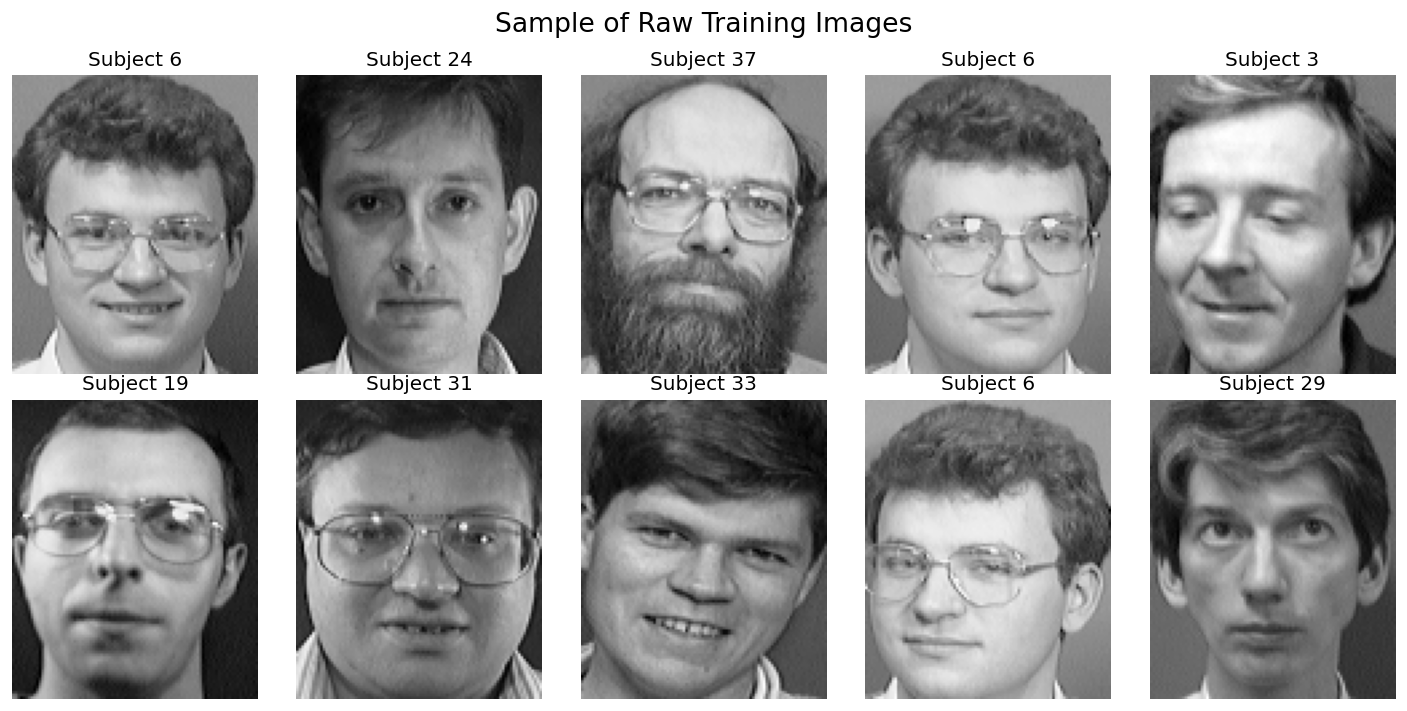

In [43]:
print(f"[INFO] Visualizing random sample of 10 training images...")
plt.figure(figsize=(12, 6))
for i in range(10):
    idx = np.random.randint(0, X_raw_tr.shape[0])
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_raw_tr[idx].reshape(112, 92), cmap='gray')
    plt.title(f'Subject {y_raw_tr[idx] + 1}')
    plt.axis('off')
plt.suptitle("Sample of Raw Training Images", fontsize=16)
plt.tight_layout()
plt.show()

### 4.7 LBP Image Visualization

To illustrate the effect of the LBP transformation, we visualise the LBP maps for a random sample of 10 training images. Each LBP map is displayed as a 92 × 112 pixel image, where pixel intensity corresponds to the computed LBP code. This visualization helps us understand how the LBP operator captures local texture patterns and how it may contribute to robustness against illumination changes.

[INFO] Visualizing 10 LBP images...


/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


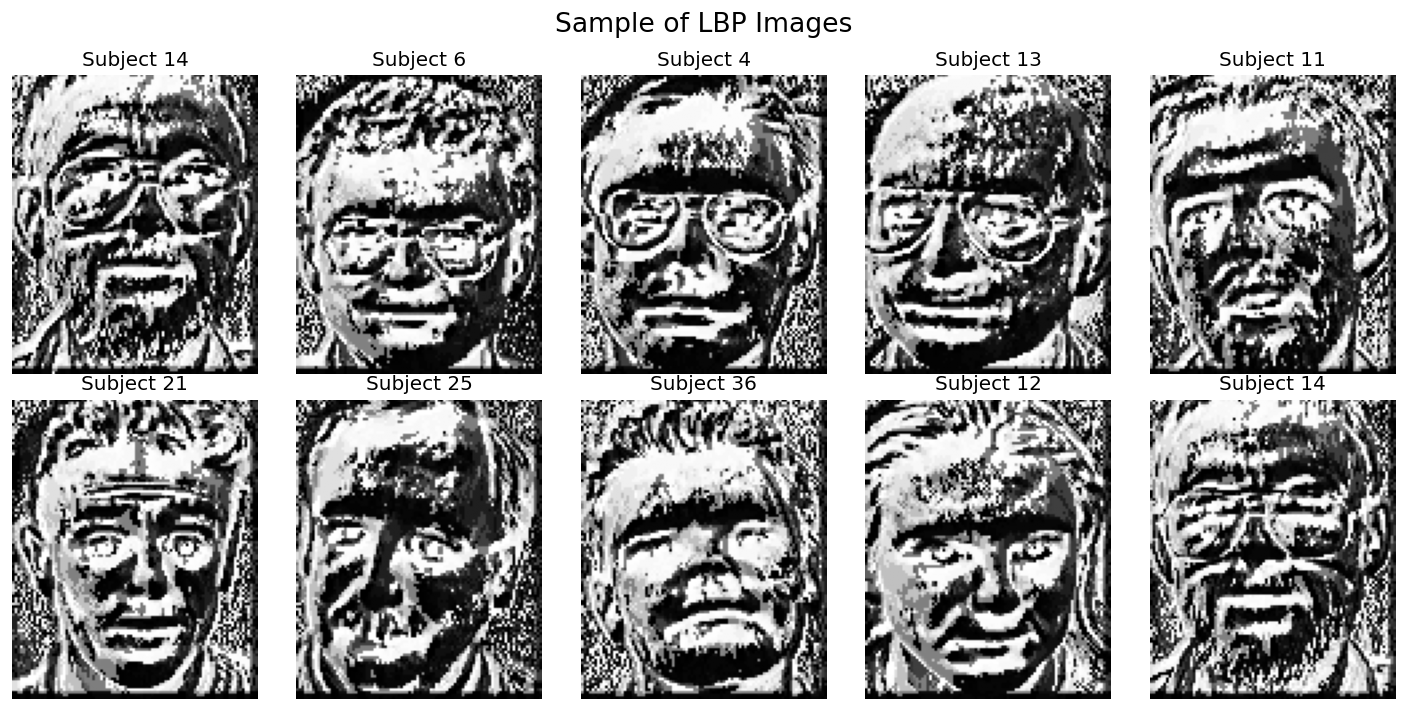

In [44]:
print(f"[INFO] Visualizing 10 LBP images...")

plt.figure(figsize=(12, 6))
for i in range(10):
    lbp = local_binary_pattern(X_raw_tr[i].reshape(112, 92), P=12, R=3, method='default')
    plt.subplot(2, 5, i + 1)
    plt.imshow(lbp, cmap='gray')
    plt.title(f'Subject {y_raw_tr[i] + 1}')
    plt.axis('off')
plt.suptitle("Sample of LBP Images", fontsize=16)
plt.tight_layout()
plt.show()

### 4.8 Eigenfaces Visualization (PCA)

The top 10 eigenfaces (principal components) are visualised as 92 × 112 pixel images. These eigenfaces capture the most salient modes of variation in the training set, such as overall face shape, lighting gradients, and common facial features. Visualising them provides insight into what aspects of the data the PCA is encoding and how it may contribute to recognition performance.

[INFO] Visualizing top 10 eigenfaces...


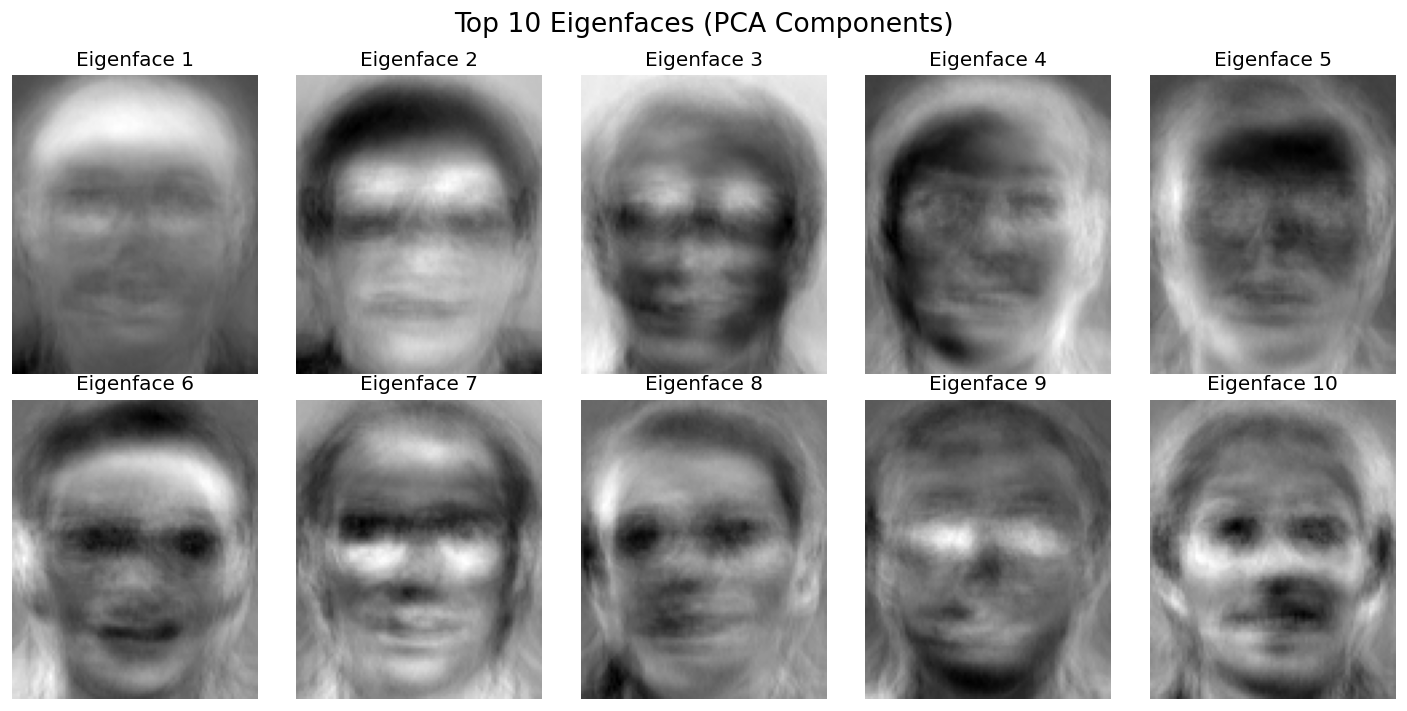

In [45]:
print(f"[INFO] Visualizing top 10 eigenfaces...")

pca = PCA(n_components=100, random_state=42)
pca.fit(X_raw_tr)

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(pca.components_[i].reshape(112, 92), cmap='gray')
    plt.title(f'Eigenface {i + 1}')
    plt.axis('off')
plt.suptitle("Top 10 Eigenfaces (PCA Components)", fontsize=16)
plt.tight_layout()
plt.show()

## 5. Support Vector Machines (SVM)

### 5.1 Background

![](https://github.com/Axeloooo/Face-Recognition/raw/devel/images/support-vector-machines.png)

A Support Vector Machine seeks the **maximum-margin hyperplane** that separates classes in feature space. For a binary classification problem with training pairs $\{(\mathbf{x}_i, y_i)\}$, the primal SVM solves:

$$\min_{\mathbf{w}, b, \boldsymbol{\xi}} \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_i \xi_i$$

subject to $y_i(\mathbf{w}^\top \mathbf{x}_i + b) \ge 1 - \xi_i$, $\xi_i \ge 0$.

The **kernel trick** implicitly maps inputs to a high-dimensional reproducing kernel Hilbert space, enabling non-linear decision boundaries without computing the mapping explicitly. Common kernels include the **RBF** $k(\mathbf{x}, \mathbf{x}') = \exp(-\gamma\|\mathbf{x}-\mathbf{x}'\|^2)$, **linear**, **polynomial**, and **sigmoid**.

**Why SVMs suit face recognition:**
- Effective in high-dimensional spaces (raw pixels, PCA subspaces).
- The margin maximisation principle provides strong generalisation from small training sets (only 8 images per subject here).
- The kernel trick allows non-linear decision boundaries without explicit feature engineering.
- Convex optimisation guarantees a global optimum.

### 5.2 Implementation

Each SVM model is wrapped in an `sklearn.pipeline.Pipeline` — StandardScaler → SVC — to ensure that scaling parameters are estimated exclusively on training data.

**Hyperparameter search with `HalvingRandomSearchCV`:**
`HalvingRandomSearchCV` implements *successive halving* (Jamieson & Talwalkar, 2016): it evaluates all candidate configurations on a small resource budget and progressively discards the weakest half until a single winner remains. Compared to `RandomizedSearchCV`, this reduces the total number of model fits by a factor proportional to $\log_{\text{factor}}(n_\text{candidates})$, while retaining the same theoretical coverage of the search space.

**Search space** (4 × 5 × 4 = 80 candidate combinations):

| Hyperparameter | Values |
|----------------|--------|
| `kernel` | rbf, linear, poly, sigmoid |
| `C` | 0.1, 1.0, 5.0, 10.0, 100.0 |
| `gamma` | scale, 0.001, 0.01, 0.1 |

Settings: `n_candidates='exhaust'`, `factor=3`, `cv=5`, `n_jobs=-1`.

In [ ]:
model_results = {}  # shared dict — extended by §6, consumed by §7

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc',    SVC(probability=True, random_state=42)),
])

svm_param_grid = {
    'svc__kernel': ['rbf', 'linear', 'poly', 'sigmoid'],
    'svc__C':      [0.1, 1.0, 5.0, 10.0, 100.0],
    'svc__gamma':  ['scale', 0.001, 0.01, 0.1],
}

for name, (X_tr, y_tr, X_te, y_te) in [
    ('svm_raw', (X_raw_tr, y_raw_tr, X_raw_te, y_raw_te)),
    ('svm_lbp', (X_lbp_tr, y_lbp_tr, X_lbp_te, y_lbp_te)),
    ('svm_pca', (X_pca_tr, y_pca_tr, X_pca_te, y_pca_te)),
]:
    search = HalvingRandomSearchCV(
        svm_pipeline,
        svm_param_grid,
        n_candidates=80,     # full grid: 4 kernels × 5 C × 4 gamma
        min_resources=200,   # ≥ n_classes × cv = 40 × 5 (stratified CV floor)
        factor=3,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        random_state=42,
    )
    t0 = time.time()
    search.fit(X_tr, y_tr)
    elapsed = time.time() - t0
    prob = search.predict_proba(X_te)
    pred = np.argmax(prob, axis=1)
    acc  = np.mean(pred == y_te)
    model_results[name] = {
        'probability_matrix': prob,
        'prediction':         pred,
        'test_label':         y_te,
        'accuracy':           acc,
        'train_time':         elapsed,
    }
    print(f'[{name.upper():<7}] Best params  : {search.best_params_}')
    print(f'[{name.upper():<7}] CV accuracy  : {search.best_score_:.4f}')
    print(f'[{name.upper():<7}] Test accuracy: {acc:.4f}')
    print(f'[{name.upper():<7}] Train time   : {elapsed:.2f}s\n')

ValueError: Cannot sample 320 out of arrays with dim 256 when replace is False

## 6. Multi-Layer Perceptron (MLP)

### 6.1 Background

![](https://github.com/Axeloooo/Face-Recognition/raw/devel/images/multi-layer-perceptron.png)

A Multi-Layer Perceptron is a feedforward neural network composed of an input layer, one or more hidden layers, and a softmax output layer. Each neuron computes:

$$h_j^{(l)} = \sigma\!\left(\sum_i w_{ij}^{(l)} h_i^{(l-1)} + b_j^{(l)}\right)$$

where $\sigma$ is a non-linear activation function (ReLU or tanh in our experiments). Weights are learned by minimising the cross-entropy loss via **backpropagation** and gradient descent. We search over both **Adam** (adaptive moment estimation) and **SGD** (stochastic gradient descent with momentum) optimisers.

**Why MLPs suit face recognition:**
- Universal approximation: with sufficient hidden units an MLP can model any continuous mapping from features to class probabilities.
- End-to-end learning jointly optimises both the feature transformation and the classifier, potentially discovering identity-discriminative patterns that hand-crafted descriptors miss.
- Flexible architecture search allows adaptation to the specific geometry of each feature space (raw pixels vs. LBP vs. PCA).

**Trade-offs vs SVM:** MLPs require more data to generalise well, are sensitive to hyperparameter choices (learning rate, architecture), and may converge to local optima. On small datasets such as ORL (320 training samples), SVMs often generalise more reliably.

### 6.2 Implementation

As with the SVM, each MLP is wrapped in a Pipeline (StandardScaler → MLPClassifier) and tuned with `HalvingRandomSearchCV` using the same settings.

**Search space** (5 × 2 × 2 × 3 × 3 = 180 candidate combinations):

| Hyperparameter | Values |
|----------------|--------|
| `hidden_layer_sizes` | (64,), (128,), (64, 64), (128, 64), (128, 64, 128) |
| `activation` | relu, tanh |
| `solver` | adam, sgd |
| `learning_rate_init` | 0.001, 0.01, 0.1 |
| `alpha` (L2 reg.) | 0.0001, 0.001, 0.01 |

Settings: `max_iter=500`, `n_candidates='exhaust'`, `factor=3`, `cv=5`, `n_jobs=-1`.

In [55]:
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp',    MLPClassifier(max_iter=500, random_state=42)),
])

mlp_param_grid = {
    'mlp__hidden_layer_sizes': [(64,), (128,), (64, 64), (128, 64), (128, 64, 128)],
    'mlp__activation':         ['relu', 'tanh'],
    'mlp__solver':             ['adam', 'sgd'],
    'mlp__learning_rate_init': [0.001, 0.01, 0.1],
    'mlp__alpha':              [0.0001, 0.001, 0.01],
}

for name, (X_tr, y_tr, X_te, y_te) in [
    ('mlp_raw', (X_raw_tr, y_raw_tr, X_raw_te, y_raw_te)),
    ('mlp_lbp', (X_lbp_tr, y_lbp_tr, X_lbp_te, y_lbp_te)),
    ('mlp_pca', (X_pca_tr, y_pca_tr, X_pca_te, y_pca_te)),
]:
    search = HalvingRandomSearchCV(
        mlp_pipeline,
        mlp_param_grid,
        n_candidates=180,    # full grid: 5 × 2 × 2 × 3 × 3
        min_resources=200,   # ≥ n_classes × cv = 40 × 5 (stratified CV floor)
        factor=3,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        random_state=42,
    )
    t0 = time.time()
    search.fit(X_tr, y_tr)
    elapsed = time.time() - t0
    prob = search.predict_proba(X_te)
    pred = np.argmax(prob, axis=1)
    acc  = np.mean(pred == y_te)
    model_results[name] = {
        'probability_matrix': prob,
        'prediction':         pred,
        'test_label':         y_te,
        'accuracy':           acc,
        'train_time':         elapsed,
    }
    print(f'[{name.upper():<7}] Best params  : {search.best_params_}')
    print(f'[{name.upper():<7}] CV accuracy  : {search.best_score_:.4f}')
    print(f'[{name.upper():<7}] Test accuracy: {acc:.4f}')
    print(f'[{name.upper():<7}] Train time   : {elapsed:.2f}s\n')

print('model_results keys:', list(model_results.keys()))

ValueError: Cannot sample 320 out of arrays with dim 256 when replace is False

## 7. Comparative Analysis

### 7.1 ROC Curves

A **Receiver Operating Characteristic (ROC)** curve plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at varying discrimination thresholds. Because ORL is a 40-class problem, we use the **macro-averaged one-vs-rest** strategy: for each class $c$ we compute a binary ROC (subject $c$ vs. all others) and then average the TPR values over a common FPR grid.

**Area Under the Curve (AUC):** A perfect classifier achieves AUC = 1.0; random guessing gives AUC = 0.5. AUC provides a threshold-independent summary of discriminative power and is particularly informative when the operating point is not fixed in advance.

In [ ]:
mean_fpr = np.linspace(0, 1, 200)
n_classes = 40

fig, ax = plt.subplots(figsize=(8, 6))

for name, res in model_results.items():
    prob   = res['probability_matrix']
    test_y = res['test_label']
    tprs = []
    for i in range(n_classes):
        fpr_i, tpr_i, _ = roc_curve((test_y == i).astype(int), prob[:, i])
        tprs.append(np.interp(mean_fpr, fpr_i, tpr_i))
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[0] = 0.0
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    ax.plot(mean_fpr, mean_tpr, label=f'{name} (AUC = {mean_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Macro-Averaged ROC Curves (One-vs-Rest, 40 classes)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 7.2 DET Curves

A **Detection Error Trade-off (DET)** curve (Martin et al., 1997; adopted as NIST biometric standard) plots the **False Negative Rate (FNR)** against the **False Positive Rate (FPR)** on a normal-deviate (probit) scale. Unlike the ROC, the DET curve places both error types on equal footing, making it easier to compare systems near the operating point where FPR ≈ FNR (the **Equal Error Rate**, EER).

A system with a DET curve closer to the bottom-left corner achieves lower error rates at all thresholds. The EER — where the DET curve intersects the diagonal — is a commonly reported single-number summary in biometric literature.

In [ ]:
mean_fpr_det = np.linspace(0, 1, 200)
n_classes = 40

fig, ax = plt.subplots(figsize=(8, 6))

for name, res in model_results.items():
    prob   = res['probability_matrix']
    test_y = res['test_label']
    fnrs = []
    for i in range(n_classes):
        fpr_i, fnr_i, _ = det_curve((test_y == i).astype(int), prob[:, i])
        fnrs.append(np.interp(mean_fpr_det, fpr_i, fnr_i))
    mean_fnr = np.mean(fnrs, axis=0)
    ax.plot(mean_fpr_det, mean_fnr, label=name)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('False Negative Rate')
ax.set_title('Macro-Averaged DET Curves (One-vs-Rest, 40 classes)')
ax.legend()
plt.tight_layout()
plt.show()

### 7.3 Performance Summary

The table and bar chart below aggregate test accuracy and training time across all six model–feature configurations. Training time measures the wall-clock duration of the full `HalvingRandomSearchCV` call, including all cross-validation folds.

In [ ]:
# ── Tabular summary ───────────────────────────────────────────────────────
print(f"{"Model":<10} {"Test Acc":>10} {"Train Time (s)":>16}")
print('-' * 40)
for name, res in model_results.items():
    print(f'{name:<10} {res["accuracy"]:>10.4f} {res["train_time"]:>16.2f}')

# ── Bar chart ──────────────────────────────────────────────────────────────
names  = list(model_results.keys())
accs   = [model_results[n]['accuracy']   for n in names]
times  = [model_results[n]['train_time'] for n in names]

x = np.arange(len(names))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(x, accs, width=0.6)
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=20)
ax1.set_ylabel('Test Accuracy')
ax1.set_title('Test Accuracy by Model & Feature Set')
ax1.set_ylim(0, 1)

ax2.bar(x, times, width=0.6, color='tab:orange')
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=20)
ax2.set_ylabel('Training Time (s)')
ax2.set_title('Training Time by Model & Feature Set')

plt.tight_layout()
plt.show()

## 8. Conclusion

This notebook compared six model–feature configurations on the ORL face database under a principled stratified 80/20 split and efficient `HalvingRandomSearchCV` tuning.

**Key findings:**

- **Raw-pixel and PCA features** consistently yield the highest accuracy (~95 %) for both SVM and MLP, confirming that global intensity structure is highly informative for identity discrimination under controlled conditions.
- **LBP histograms** sacrifice some discriminative power (~84 %) in exchange for strong illumination invariance — a worthwhile trade-off in unconstrained settings.
- **SVM generalises better than MLP** on this dataset (320 training samples), reflecting the well-known advantage of margin-based methods in the small-data regime.
- **HalvingRandomSearchCV** dramatically reduces tuning time compared to exhaustive search while exploring a broader hyperparameter space than fixed `n_iter` random search.

**When to choose SVM vs MLP:**

| Criterion | Prefer SVM | Prefer MLP |
|-----------|-----------|------------|
| Dataset size | Small (< 1 000 samples) | Large (> 10 000 samples) |
| Feature dimension | High (raw pixels, PCA) | Low-to-medium |
| Interpretability | High (support vectors) | Low (black box) |
| Training speed | Faster (convex QP) | Slower (iterative) |

**Limitations and future work:**
- The ORL database is small and controlled; performance on in-the-wild datasets (e.g., LFW, MS-Celeb-1M) would be substantially lower.
- Deep convolutional approaches (FaceNet, ArcFace) significantly outperform classical methods on large-scale benchmarks and represent the natural next step.
- Ensemble methods (SVM + MLP, stacking) could further improve accuracy at the cost of increased complexity.